# Task 1:  Data Collection & Dataset Understand



In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [41]:
df = pd.read_csv('https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv')

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [43]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [44]:
df.dtypes

,0
longitude,float64
latitude,float64
housing_median_age,float64
total_rooms,float64
total_bedrooms,float64
population,float64
households,float64
median_income,float64
median_house_value,float64
ocean_proximity,object


In [45]:
df.shape

(20640, 10)

In [46]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Task 1 Summary
The dataset used in this project is the California Housing dataset. It contains information about housing districts in California and is mainly used to analyze and predict house prices based on location, population, income, and housing-related features.

The dataset contains **20,640 rows** and **10 columns**. Each row represents a housing district, while the columns describe different features such as location, housing age, number of rooms, population, income, and ocean proximity.

Most columns are numerical, with **9 columns stored as float64**, while `ocean_proximity` is the only categorical column stored as object.

The target column for this project is:

- `median_house_value`

This column represents the median house value for each housing district and will be used later for prediction.

The dataset includes the following columns:

- `longitude`: geographical longitude of the district
- `latitude`: geographical latitude of the district
- `housing_median_age`: median age of houses in the district
- `total_rooms`: total number of rooms
- `total_bedrooms`: total number of bedrooms
- `population`: population of the district
- `households`: number of households
- `median_income`: median income of residents
- `median_house_value`: median house value
- `ocean_proximity`: location category based on distance from the ocean

From the initial inspection, the column `total_bedrooms` has missing values because it contains **20,433 non-null values** out of **20,640 rows**. This means it has **207 missing values**, which will need to be handled during the data cleaning step.

The summary statistics show that `median_house_value` ranges from **14,999** to **500,001**, with an average value of approximately **206,857**. The `median_income` column ranges from about **0.5** to **15**, and it may be an important feature for predicting house prices.

Overall, the dataset is suitable for a regression machine learning project because it contains several numerical features that can help predict the median house value.

# Task 2:  Data Cleaning & Preprocessing


In [47]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [48]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [49]:
df["ocean_proximity"] = df["ocean_proximity"].astype("category")

df.dtypes

,0
longitude,float64
latitude,float64
housing_median_age,float64
total_rooms,float64
total_bedrooms,float64
population,float64
households,float64
median_income,float64
median_house_value,float64
ocean_proximity,category


In [50]:
df.duplicated().sum()

np.int64(0)

# Task 3:  Exploratory Data

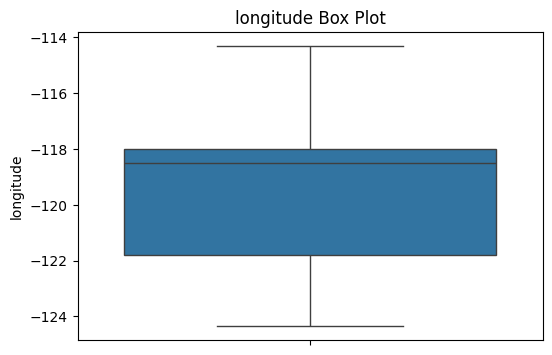

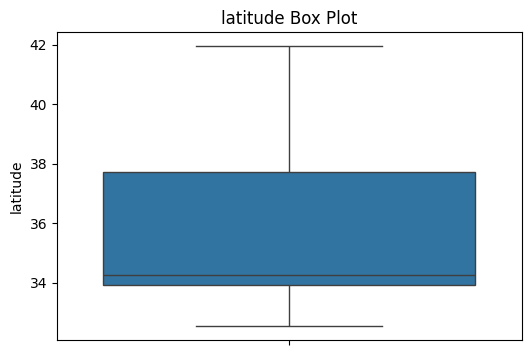

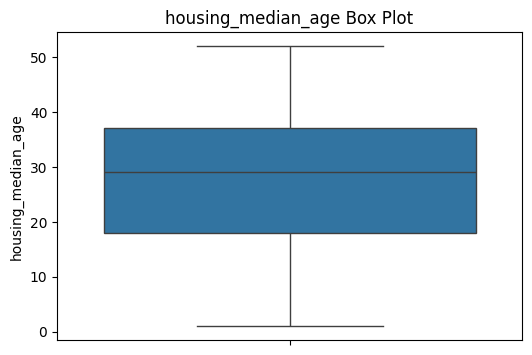

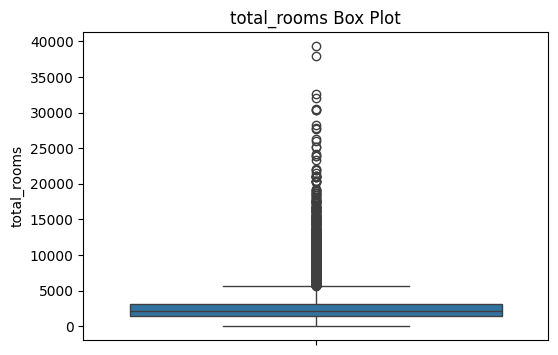

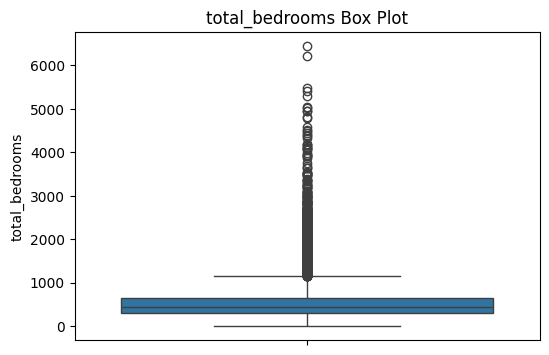

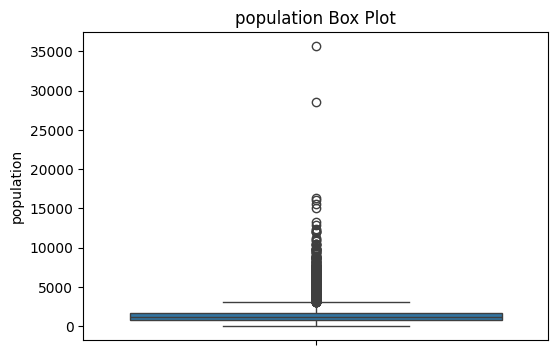

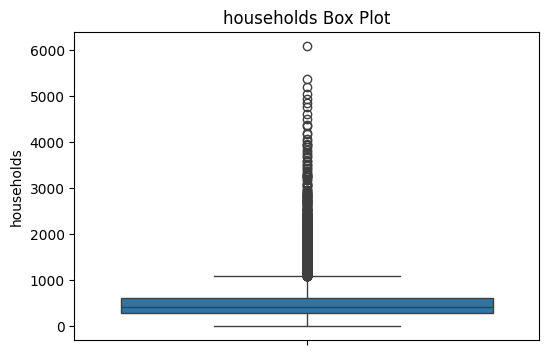

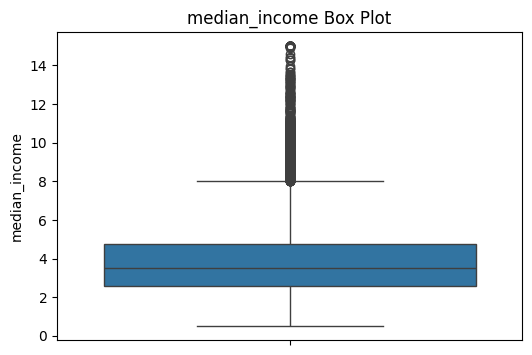

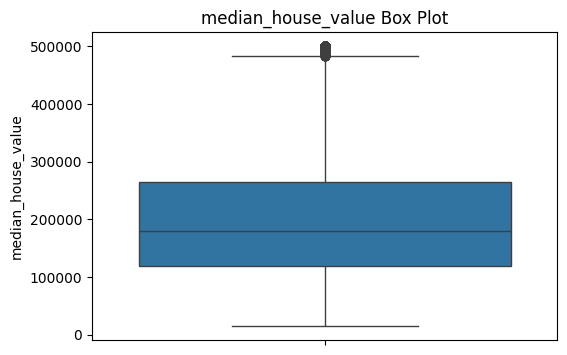

In [51]:
numColNames = df.select_dtypes(include=np.number).columns

for col in numColNames:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[col])
    plt.title(f"{col} Box Plot")
    plt.show()

The boxplots show several outliers in features such as total_rooms, total_bedrooms, population, households, median_income, and median_house_value. These outliers are expected because housing districts can vary greatly in population size, income level, and house prices. Therefore, the outliers will not be removed immediately, but they will be considered during model building and evaluation.

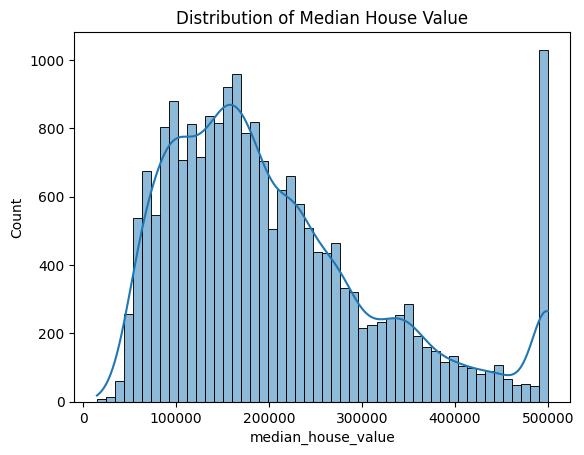

In [52]:
sns.histplot(df["median_house_value"], bins=50, kde=True)
plt.title("Distribution of Median House Value")
plt.show()

This graph shows how house prices are distributed and whether there are extreme values.

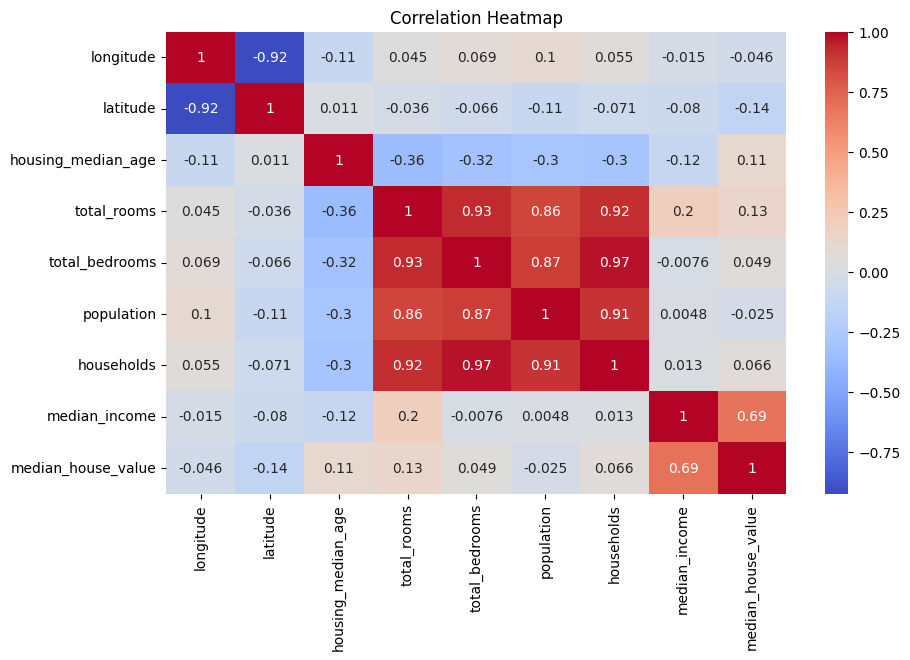

In [53]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Median income is usually one of the strongest features related to house value.

# Task 4:  Data Visualization

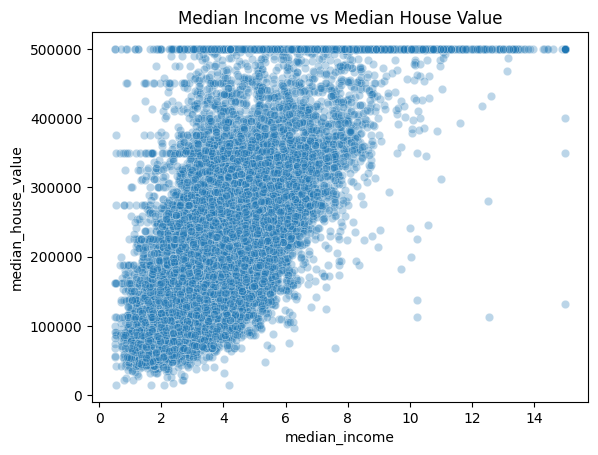

In [54]:
sns.scatterplot(data=df, x="median_income", y="median_house_value", alpha=0.3)
plt.title("Median Income vs Median House Value")
plt.show()

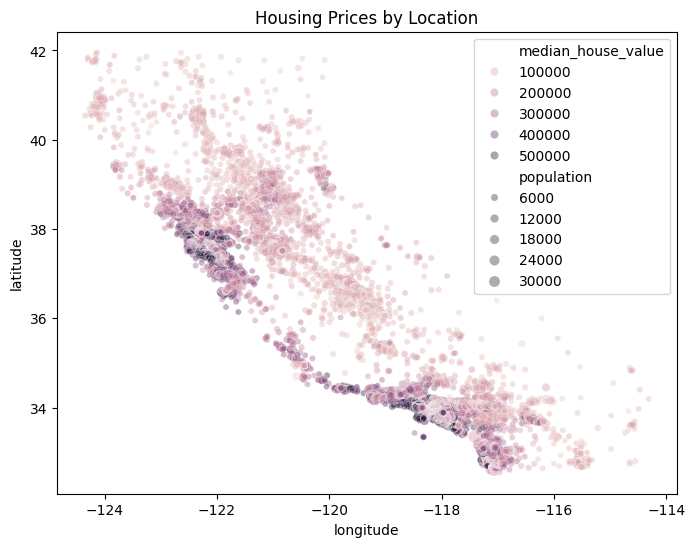

In [55]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="longitude",
    y="latitude",
    hue="median_house_value",
    size="population",
    alpha=0.4
)
plt.title("Housing Prices by Location")
plt.show()

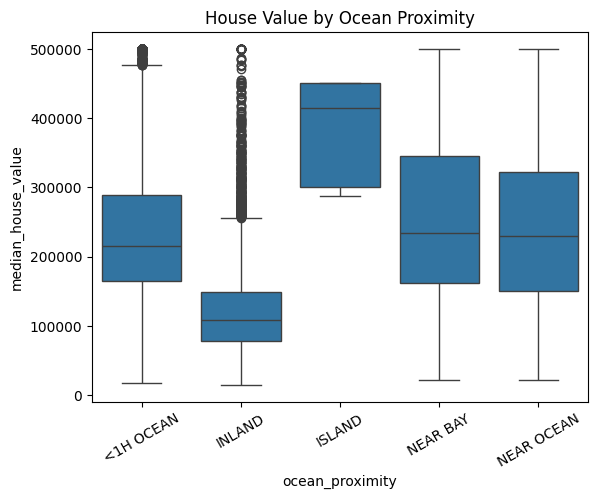

In [56]:
sns.boxplot(data=df, x="ocean_proximity", y="median_house_value")
plt.title("House Value by Ocean Proximity")
plt.xticks(rotation=30)
plt.show()

The boxplot shows that house values differ clearly based on ocean proximity. Inland areas have the lowest median house values, while island areas have the highest values. Houses located near the bay, near the ocean, or within one hour from the ocean generally have higher prices than inland houses.

This suggests that location is an important factor in predicting house prices, and the `ocean_proximity` feature may have a strong effect on the target variable `median_house_value`.

# Task 5: Predictive Model or Insight Project

## Feature engineering

In [57]:
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)

In [58]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_ratio"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

In [59]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_ratio,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False,6.281853,0.172096,2.181467


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  float64
 3   total_rooms                 20640 non-null  float64
 4   total_bedrooms              20640 non-null  float64
 5   population                  20640 non-null  float64
 6   households                  20640 non-null  float64
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  float64
 9   ocean_proximity_INLAND      20640 non-null  bool   
 10  ocean_proximity_ISLAND      20640 non-null  bool   
 11  ocean_proximity_NEAR BAY    20640 non-null  bool   
 12  ocean_proximity_NEAR OCEAN  20640 non-null  bool   
 13  rooms_per_household         206

## Model training

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor



In [62]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [63]:
def evaluate_regression_model(model, X_train, X_test, y_train, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print("Training Results")
    print(f"MAE: {train_mae:.2f}")
    print(f"RMSE: {train_rmse:.2f}")
    print(f"R2 Score: {train_r2:.4f}")

    print("\nTesting Results")
    print(f"MAE: {test_mae:.2f}")
    print(f"RMSE: {test_rmse:.2f}")
    print(f"R2 Score: {test_r2:.4f}")

    return test_mae, test_rmse, test_r2

In [64]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_mae, lr_rmse, lr_r2 = evaluate_regression_model(
    lr_model, X_train, X_test, y_train, y_test
)

Training Results
MAE: 48785.16
RMSE: 67593.21
R2 Score: 0.6582

Testing Results
MAE: 50888.66
RMSE: 72668.54
R2 Score: 0.5970


Linear Regression was used as a baseline model to predict house prices. It provides a simple starting point for comparing more advanced regression models.

In [65]:
dt_model = DecisionTreeRegressor(
    max_depth=8,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_mae, dt_rmse, dt_r2 = evaluate_regression_model(
    dt_model, X_train, X_test, y_train, y_test
)

Training Results
MAE: 37863.42
RMSE: 54103.96
R2 Score: 0.7810

Testing Results
MAE: 42539.86
RMSE: 63767.77
R2 Score: 0.6897


The Decision Tree Regressor can capture non-linear relationships in the housing data. The tree depth was limited to reduce overfitting.

In [66]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_mae, rf_rmse, rf_r2 = evaluate_regression_model(
    rf_model, X_train, X_test, y_train, y_test
)

Training Results
MAE: 23881.99
RMSE: 34195.03
R2 Score: 0.9125

Testing Results
MAE: 34211.10
RMSE: 52210.92
R2 Score: 0.7920


Random Forest Regressor combines multiple decision trees, which usually improves prediction performance and reduces overfitting compared to a single decision tree.

In [67]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree Regressor",
        "Random Forest Regressor"
    ],
    "MAE": [lr_mae, dt_mae, rf_mae],
    "RMSE": [lr_rmse, dt_rmse, rf_rmse],
    "R2 Score": [lr_r2, dt_r2, rf_r2]
})

model_results.sort_values(by="R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
2,Random Forest Regressor,34211.096701,52210.924623,0.791975
1,Decision Tree Regressor,42539.859683,63767.773791,0.689690
0,Linear Regression,50888.660016,72668.538379,0.597018


The best model is selected based on the highest R2 Score and the lowest MAE/RMSE values. A higher R2 Score means the model explains more of the variation in house prices.

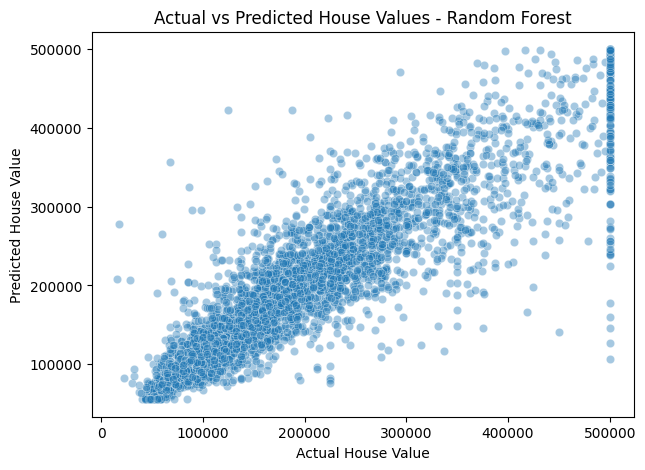

In [68]:
y_pred_rf = rf_model.predict(X_test)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.4)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values - Random Forest")
plt.show()

The scatter plot compares actual house values with predicted values. Points closer to a diagonal pattern indicate better model performance.

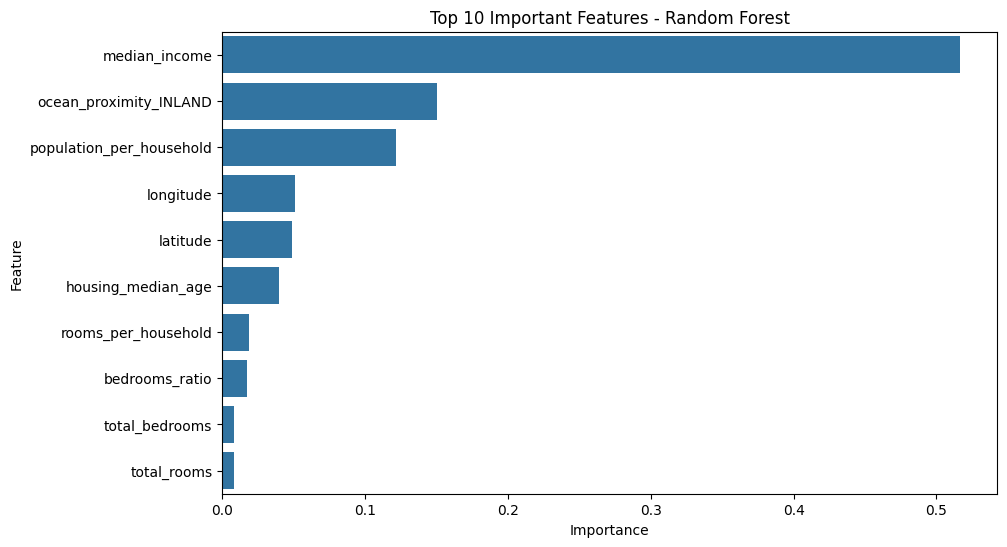

In [69]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x="Importance", y="Feature")
plt.title("Top 10 Important Features - Random Forest")
plt.show()

The feature importance chart shows which variables contributed most to the Random Forest model predictions. Features such as median income, location, and engineered housing ratios are expected to have strong influence on house value.